In [7]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
plt.style.use("fivethirtyeight")
sns.set_style("darkgrid")
import warnings
warnings.filterwarnings(action="ignore")

In [8]:
# LOADING THE DATA 

In [9]:
df = pd.read_csv("emotions.csv")

In [10]:
# PRINTING THE FIRST FIVE ROWS 

In [11]:
df.head()

,# mean_0_a,mean_1_a,mean_2_a,mean_3_a,mean_4_a,mean_d_0_a,mean_d_1_a,mean_d_2_a,mean_d_3_a,mean_d_4_a,...,fft_741_b,fft_742_b,fft_743_b,fft_744_b,fft_745_b,fft_746_b,fft_747_b,fft_748_b,fft_749_b,label
0,4.62,30.3,-356.0,15.6,26.3,1.070,0.411,-15.70,2.06,3.15,...,23.5,20.3,20.3,23.5,-215.0,280.00,-162.00,-162.00,280.00,NEGATIVE
1,28.80,33.1,32.0,25.8,22.8,6.550,1.680,2.88,3.83,-4.82,...,-23.3,-21.8,-21.8,-23.3,182.0,2.57,-31.60,-31.60,2.57,NEUTRAL
2,8.90,29.4,-416.0,16.7,23.7,79.900,3.360,90.20,89.90,2.03,...,462.0,-233.0,-233.0,462.0,-267.0,281.00,-148.00,-148.00,281.00,POSITIVE
3,14.90,31.6,-143.0,19.8,24.3,-0.584,-0.284,8.82,2.30,-1.97,...,299.0,-243.0,-243.0,299.0,132.0,-12.40,9.53,9.53,-12.40,POSITIVE
4,28.30,31.3,45.2,27.3,24.5,34.800,-5.790,3.06,41.40,5.52,...,12.0,38.1,38.1,12.0,119.0,-17.60,23.90,23.90,-17.60,NEUTRAL


In [12]:
df.tail()

,# mean_0_a,mean_1_a,mean_2_a,mean_3_a,mean_4_a,mean_d_0_a,mean_d_1_a,mean_d_2_a,mean_d_3_a,mean_d_4_a,...,fft_741_b,fft_742_b,fft_743_b,fft_744_b,fft_745_b,fft_746_b,fft_747_b,fft_748_b,fft_749_b,label
2127,32.400,32.2,32.2,30.80,23.4,1.64,-2.03,0.647,-0.121,-1.10,...,-21.70,0.218,0.218,-21.70,95.2,-19.90,47.2,47.2,-19.90,NEUTRAL
2128,16.300,31.3,-284.0,14.30,23.9,4.20,1.09,4.460,4.720,6.63,...,594.00,-324.000,-324.000,594.00,-35.5,142.00,-59.8,-59.8,142.00,POSITIVE
2129,-0.547,28.3,-259.0,15.80,26.7,9.08,6.90,12.700,2.030,4.64,...,370.00,-160.000,-160.000,370.00,408.0,-169.00,-10.5,-10.5,-169.00,NEGATIVE
2130,16.800,19.9,-288.0,8.34,26.0,2.46,1.58,-16.000,1.690,4.74,...,124.00,-27.600,-27.600,124.00,-656.0,552.00,-271.0,-271.0,552.00,NEGATIVE
2131,27.000,32.0,31.8,25.00,28.9,4.99,1.95,6.210,3.490,-3.51,...,1.95,1.810,1.810,1.95,110.0,-6.71,22.8,22.8,-6.71,NEUTRAL


In [13]:
# PRINTING THE NUMBER OF ROWS AND COLUMNS 

In [14]:
print(f"Dataset has {df.shape[1]} columns and {df.shape[0]} rows")

Dataset has 2549 columns and 2132 rows


In [15]:
# CHECKING THE VALUES WHETHER THEY ARE NULL/NON NULL DISTRIBUTIONS 

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2132 entries, 0 to 2131
Columns: 2549 entries, # mean_0_a to label
dtypes: float64(2548), object(1)
memory usage: 41.5+ MB


In [17]:
# PERCENTAGE OF NULL VALUES 
(df.isna().sum())/len(df)

# mean_0_a    0.0
mean_1_a      0.0
mean_2_a      0.0
mean_3_a      0.0
mean_4_a      0.0
             ... 
fft_746_b     0.0
fft_747_b     0.0
fft_748_b     0.0
fft_749_b     0.0
label         0.0
Length: 2549, dtype: float64

In [18]:
# CHECKING DISTRIBUTION OF NUMERICAL VALUES IN THE DATASET 

In [19]:
df.describe()

,# mean_0_a,mean_1_a,mean_2_a,mean_3_a,mean_4_a,mean_d_0_a,mean_d_1_a,mean_d_2_a,mean_d_3_a,mean_d_4_a,...,fft_740_b,fft_741_b,fft_742_b,fft_743_b,fft_744_b,fft_745_b,fft_746_b,fft_747_b,fft_748_b,fft_749_b
count,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,...,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000
mean,15.256914,27.012462,-104.975629,13.605898,24.150483,0.025378,0.052282,0.301655,0.036793,0.083567,...,-22.938971,104.946111,-51.973647,-51.973647,104.946111,-6.934144,95.104886,-49.061255,-49.061255,95.104886
std,15.284621,9.265141,206.271960,16.874676,14.187340,17.981796,8.509174,68.098894,17.010031,18.935378,...,298.034311,212.532721,112.160233,112.160233,212.532721,281.040552,203.194976,106.486317,106.486317,203.194976
min,-61.300000,-114.000000,-970.000000,-137.000000,-217.000000,-218.000000,-255.000000,-1360.000000,-203.000000,-553.000000,...,-1180.000000,-921.000000,-504.000000,-504.000000,-921.000000,-1160.000000,-1010.000000,-521.000000,-521.000000,-1010.000000
25%,6.577500,26.075000,-195.000000,4.857500,23.600000,-3.105000,-1.340000,-4.002500,-2.905000,-2.622500,...,-106.500000,-8.365000,-92.900000,-92.900000,-8.365000,-102.500000,-8.837500,-87.150000,-87.150000,-8.837500
50%,14.100000,30.000000,14.950000,15.400000,25.200000,-0.044600,0.132000,0.957500,-0.099750,0.146500,...,83.850000,12.150000,-21.800000,-21.800000,12.150000,89.700000,13.400000,-24.100000,-24.100000,13.400000
75%,27.700000,31.400000,29.600000,26.500000,26.800000,2.920000,1.540000,6.735000,2.535000,2.870000,...,154.000000,177.000000,12.025000,12.025000,177.000000,153.000000,149.250000,10.925000,10.925000,149.250000
max,304.000000,42.300000,661.000000,206.000000,213.000000,402.000000,257.000000,1150.000000,349.000000,444.000000,...,1070.000000,843.000000,1490.000000,1490.000000,843.000000,1180.000000,888.000000,1670.000000,1670.000000,888.000000


In [20]:
# CHECKING THE CLASS DISTRIBUTION OF THE TARGET VARIABLE 
df['label'].value_counts()

label
NEUTRAL     716
NEGATIVE    708
POSITIVE    708
Name: count, dtype: int64

label
NEGATIVE    33.208255
NEUTRAL     33.583490
POSITIVE    33.208255
Name: label, dtype: float64


<Axes: ylabel='label'>

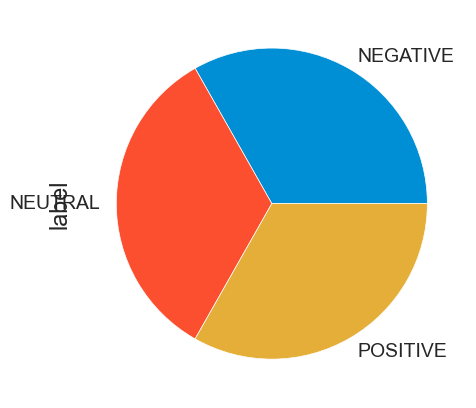

In [21]:
# CHECKING THE CLASS DISTRIBUTION OF THE TARGET VARIABLE IN PERCENTAGE 
print((df.groupby('label')['label'].count()/df['label'].count()) *100)
((df.groupby('label')['label'].count()/df['label'].count()) *100).plot.pie()

In [22]:
# CHECKING THE CORRELATION 
corr = df.select_dtypes(include=['number']).corr()
corr

,# mean_0_a,mean_1_a,mean_2_a,mean_3_a,mean_4_a,mean_d_0_a,mean_d_1_a,mean_d_2_a,mean_d_3_a,mean_d_4_a,...,fft_740_b,fft_741_b,fft_742_b,fft_743_b,fft_744_b,fft_745_b,fft_746_b,fft_747_b,fft_748_b,fft_749_b
# mean_0_a,1.000000,0.176578,0.429810,0.582697,0.178432,-0.000665,0.105961,-0.061046,0.135370,0.008472,...,0.301672,-0.245671,0.204764,0.204764,-0.245671,0.268983,-0.220566,0.196653,0.196653,-0.220566
mean_1_a,0.176578,1.000000,-0.007202,0.571530,0.385041,-0.088608,-0.007586,-0.050463,-0.119391,-0.017197,...,0.130717,-0.047208,0.002549,0.002549,-0.047208,0.153244,-0.096173,0.069532,0.069532,-0.096173
mean_2_a,0.429810,-0.007202,1.000000,0.081567,-0.095696,0.015122,0.014605,-0.004320,0.055625,-0.003564,...,0.699461,-0.742275,0.622567,0.622567,-0.742275,0.674195,-0.728296,0.565044,0.565044,-0.728296
mean_3_a,0.582697,0.571530,0.081567,1.000000,0.220842,-0.117748,0.124462,-0.175592,-0.001782,0.017110,...,0.133720,-0.067460,0.048202,0.048202,-0.067460,0.103294,-0.061376,0.051216,0.051216,-0.061376
mean_4_a,0.178432,0.385041,-0.095696,0.220842,1.000000,-0.017196,-0.007570,0.025546,-0.033443,-0.020361,...,-0.043602,0.069458,-0.090163,-0.090163,0.069458,-0.039620,0.056452,-0.016933,-0.016933,0.056452
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
fft_745_b,0.268983,0.153244,0.674195,0.103294,-0.039620,0.024944,-0.043387,0.098389,-0.022019,-0.003329,...,0.458558,-0.431711,0.415781,0.415781,-0.431711,1.000000,-0.938696,0.834622,0.834622,-0.938696
fft_746_b,-0.220566,-0.096173,-0.728296,-0.061376,0.056452,0.002976,-0.001477,-0.061713,0.005671,-0.005395,...,-0.493145,0.531019,-0.459876,-0.459876,0.531019,-0.938696,1.000000,-0.815108,-0.815108,1.000000
fft_747_b,0.196653,0.069532,0.565044,0.051216,-0.016933,-0.017169,0.003350,0.149472,-0.040408,0.003422,...,0.375438,-0.355117,0.499272,0.499272,-0.355117,0.834622,-0.815108,1.000000,1.000000,-0.815108
fft_748_b,0.196653,0.069532,0.565044,0.051216,-0.016933,-0.017169,0.003350,0.149472,-0.040408,0.003422,...,0.375438,-0.355117,0.499272,0.499272,-0.355117,0.834622,-0.815108,1.000000,1.000000,-0.815108


In [23]:
# SPLITTING THE DATA INTO TRAIN AND TESTING DATA 

In [24]:
# SPLITTING THE DATASET INTO X AND Y
y= df['label']
X = df.drop(['label'], axis=1)

In [25]:
# CHECKING SOME ROWS OF X 
X.head()

,# mean_0_a,mean_1_a,mean_2_a,mean_3_a,mean_4_a,mean_d_0_a,mean_d_1_a,mean_d_2_a,mean_d_3_a,mean_d_4_a,...,fft_740_b,fft_741_b,fft_742_b,fft_743_b,fft_744_b,fft_745_b,fft_746_b,fft_747_b,fft_748_b,fft_749_b
0,4.62,30.3,-356.0,15.6,26.3,1.070,0.411,-15.70,2.06,3.15,...,74.3,23.5,20.3,20.3,23.5,-215.0,280.00,-162.00,-162.00,280.00
1,28.80,33.1,32.0,25.8,22.8,6.550,1.680,2.88,3.83,-4.82,...,130.0,-23.3,-21.8,-21.8,-23.3,182.0,2.57,-31.60,-31.60,2.57
2,8.90,29.4,-416.0,16.7,23.7,79.900,3.360,90.20,89.90,2.03,...,-534.0,462.0,-233.0,-233.0,462.0,-267.0,281.00,-148.00,-148.00,281.00
3,14.90,31.6,-143.0,19.8,24.3,-0.584,-0.284,8.82,2.30,-1.97,...,-183.0,299.0,-243.0,-243.0,299.0,132.0,-12.40,9.53,9.53,-12.40
4,28.30,31.3,45.2,27.3,24.5,34.800,-5.790,3.06,41.40,5.52,...,114.0,12.0,38.1,38.1,12.0,119.0,-17.60,23.90,23.90,-17.60


In [26]:
# CHECKING SOME ROWS OF Y 
y.head()

0    NEGATIVE
1     NEUTRAL
2    POSITIVE
3    POSITIVE
4     NEUTRAL
Name: label, dtype: object

In [27]:
# SPLITTING THE DATASET USING TRAIN TEST SPLIT 
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=100, test_size=0.20)

In [28]:
# CHECKING THE SPREAD OF DATA SPLIT 
print(np.sum(y))
print(np.sum(y_train))
print(np.sum(y_test))

...


In [29]:
# IMPLEMENTING CATBOOST CLASSIFIER 

In [30]:
# First, we need to define the cat_classifier before using it
from catboost import CatBoostClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# Convert string labels to numerical values
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Initialize the CatBoost classifier
cat_classifier = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    random_seed=42,
    early_stopping_rounds=20,  # This parameter needs to be used with eval_set
    verbose=False  # Optional: reduces output during training
)

# Train the model with encoded labels and provide validation data for early stopping
# We need to provide an evaluation set for early stopping to work
cat_classifier.fit(
    X_train, 
    y_train_encoded,
    eval_set=[(X_test, y_test_encoded)],  # Add this line to enable early stopping
    verbose=False  # Optional: reduces output during training
)

# Make predictions
y_pred1 = cat_classifier.predict(X_test)

# For classification report and accuracy, we can use the encoded predictions directly
report1 = classification_report(y_test_encoded, y_pred1)
print(report1)
print(f"Accuracy: {accuracy_score(y_test_encoded, y_pred1)}")

# For ROC AUC score, we need probabilities
if len(label_encoder.classes_) == 2:
    # Binary classification case
    y_pred_proba = cat_classifier.predict_proba(X_test)[:, 1]  # Get probability for positive class
    print(f"ROC AUC Score for Cat Boost Classifier: {roc_auc_score(y_test_encoded, y_pred_proba)}")
else:
    # Multiclass case - use predict_proba which returns probabilities for each class
    y_pred_proba = cat_classifier.predict_proba(X_test)  # Get probabilities for all classes
    print(f"ROC AUC Score for Cat Boost Classifier: {roc_auc_score(y_test_encoded, y_pred_proba, multi_class='ovr')}")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       154
           1       1.00      0.99      0.99       148
           2       0.98      1.00      0.99       125

    accuracy                           1.00       427
   macro avg       0.99      1.00      1.00       427
weighted avg       1.00      1.00      1.00       427

Accuracy: 0.9953161592505855
ROC AUC Score for Cat Boost Classifier: 0.9999051420572463


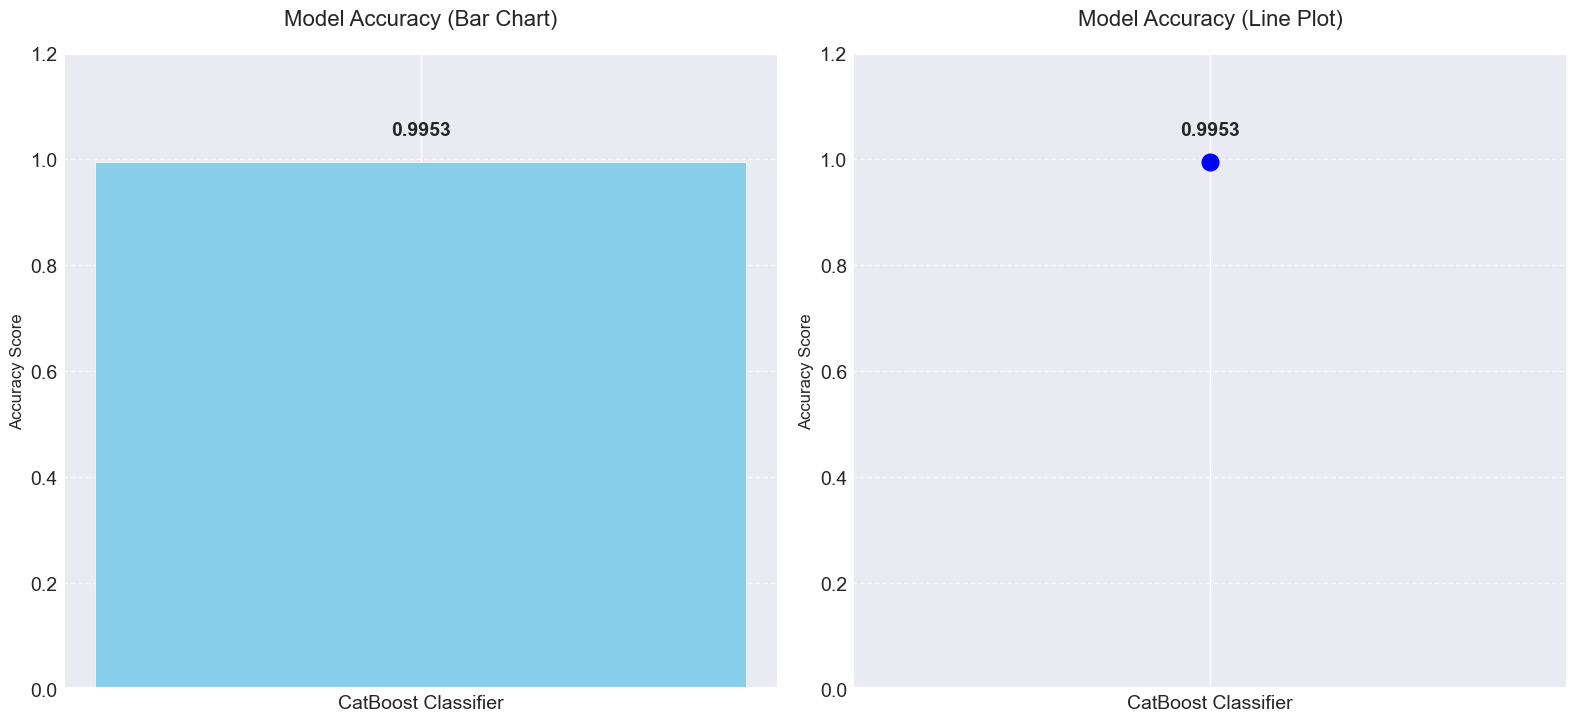

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Get the accuracy value
accuracy = accuracy_score(y_test_encoded, y_pred1)

# A. Bar chart (left subplot)
ax1.bar(['CatBoost Classifier'], [accuracy], color='skyblue', width=0.1)  # Very narrow bar
ax1.set_ylim(0, 1.2)
ax1.set_ylabel('Accuracy Score', fontsize=12)
ax1.set_title('Model Accuracy (Bar Chart)', fontsize=16, pad=20)
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.text(0, accuracy + 0.05, f"{accuracy:.4f}", ha='center', fontsize=14, fontweight='bold')

# B. Line plot with marker (right subplot)
ax2.plot(['CatBoost Classifier'], [accuracy], 'o-', markersize=12, linewidth=2, color='blue')
ax2.set_ylim(0, 1.2)
ax2.set_ylabel('Accuracy Score', fontsize=12)
ax2.set_title('Model Accuracy (Line Plot)', fontsize=16, pad=20)
ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.text(0, accuracy + 0.05, f"{accuracy:.4f}", ha='center', fontsize=14, fontweight='bold')

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(top=0.85)

plt.show()

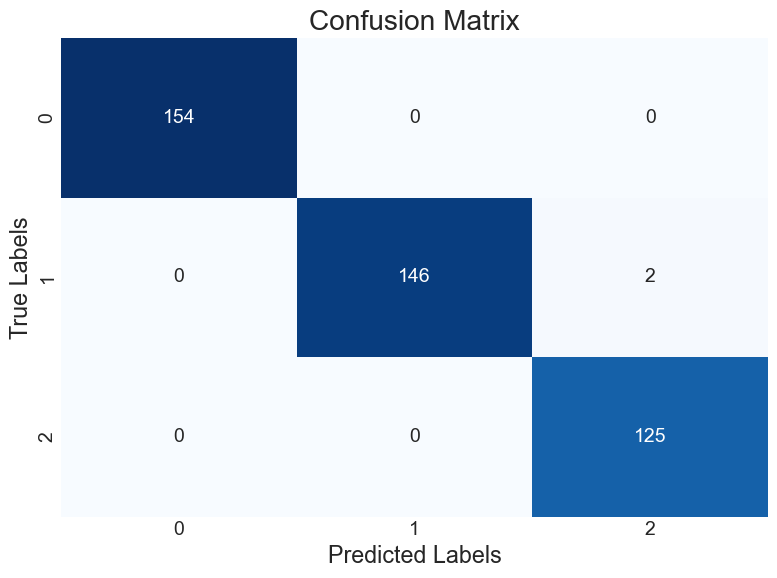

In [32]:
# 2. Create a confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_encoded, y_pred1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

Number of classes: 3
Classes: ['NEGATIVE' 'NEUTRAL' 'POSITIVE']
X_test shape: (427, 2548)
y_test_encoded shape: (427,)
Classifier exists: True


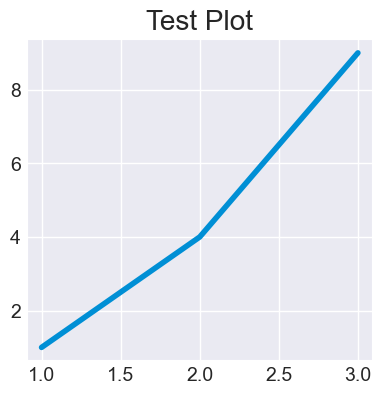

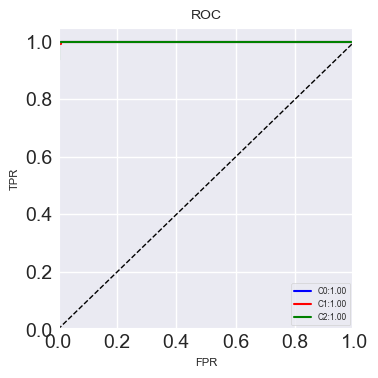

In [33]:
# 3. Create ROC curve (for binary classification)
# A. First, check if you have a multiclass classification problem
print("Number of classes:", len(label_encoder.classes_))
print("Classes:", label_encoder.classes_)

# B. Verify that your classifier and data exist and have the expected shapes
print("X_test shape:", X_test.shape)
print("y_test_encoded shape:", y_test_encoded.shape)
print("Classifier exists:", 'cat_classifier' in locals() or 'cat_classifier' in globals())

# C. Try forcing the plot to display with a simple test
import matplotlib.pyplot as plt
plt.figure(figsize=(4, 4))
plt.plot([1, 2, 3], [1, 4, 9])
plt.title("Test Plot")
plt.show()

# D. Create ROC curve for multiclass classification using One-vs-Rest approach
# Create ROC curve for multiclass classification using One-vs-Rest approach
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Get the number of classes
n_classes = len(label_encoder.classes_)

# Binarize the output for multiclass ROC
y_test_bin = label_binarize(y_test_encoded, classes=range(n_classes))

# Get prediction probabilities
y_pred_proba = cat_classifier.predict_proba(X_test)

# Plot ROC curves for each class
plt.figure(figsize=(4, 4))  # Same small size as your test plot
colors = ['blue', 'red', 'green', 'cyan', 'magenta', 'yellow', 'black']
lw = 1.5  # Thinner lines

for i in range(min(n_classes, len(colors))):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i % len(colors)], lw=lw,
             label=f'C{i}:{roc_auc:.2f}')  # Shorter labels

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('FPR', fontsize=8)
plt.ylabel('TPR', fontsize=8)
plt.title('ROC', fontsize=10)
plt.legend(loc="lower right", fontsize=6)  # Much smaller font
plt.tight_layout()
plt.show()

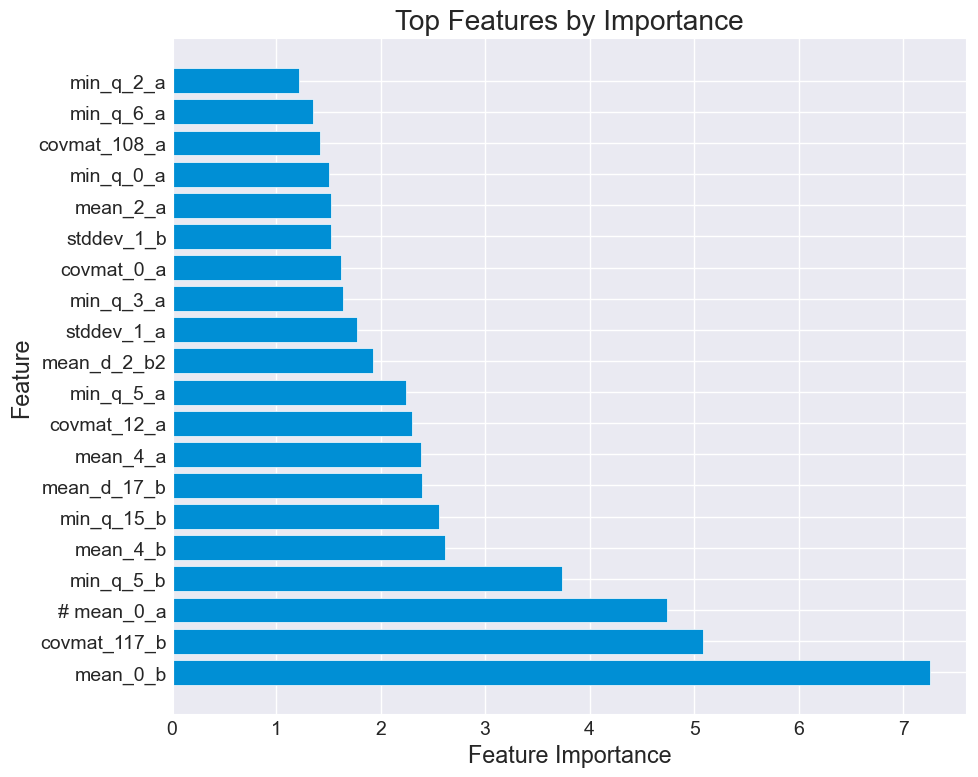

In [34]:
# 4. Feature importance plot (if available in your model)
if hasattr(cat_classifier, 'feature_importances_'):
    plt.figure(figsize=(10, 8))
    # Get feature names if available, otherwise use indices
    feature_names = X_train.columns if hasattr(X_train, 'columns') else [f'Feature {i}' for i in range(X_train.shape[1])]
    
    # Sort features by importance
    indices = np.argsort(cat_classifier.feature_importances_)[::-1]
    top_n = 20  # Show top 20 features or all if less than 20
    n_features = min(top_n, len(indices))
    
    plt.barh(range(n_features), cat_classifier.feature_importances_[indices[:n_features]], align='center')
    plt.yticks(range(n_features), [feature_names[i] for i in indices[:n_features]])
    plt.xlabel('Feature Importance')
    plt.ylabel('Feature')
    plt.title('Top Features by Importance')
    plt.tight_layout()
    plt.show()